In this example, we will use the IEEEPPG dataset @{tan2020}, which focuses on heart rate monitoring during physical exercise using wrist-type _photoplethysmographic_ (PPG) signals.
The dataset consists of two PPG signals and three-axis acceleration signals.
The goal is to predict ECG values from the PPG and acceleration signals.
All signals were sampled at 125 Hz.

### Imports

In [ ]:
# | code-fold: true

import tempfile

import matplotlib.pyplot as plt
import numpy as np
import requests
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sktime.datasets import load_from_tsfile_to_dataframe
from sktime.regression.deep_learning import CNNRegressor
from tensorflow.keras.optimizers import Adam
from tslearn.preprocessing import TimeSeriesScalerMinMax

2025-11-17 23:40:19.658184: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-17 23:40:25.899101: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Loading the dataset

In [ ]:
# | code-fold: true


def download_data(url):
    with requests.get(url, stream=True) as r:
        r.raise_for_status()

        with tempfile.NamedTemporaryFile(suffix=".ts", delete=False) as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

            fp = f.name

    X, y = load_from_tsfile_to_dataframe(fp)

    return X, y


testdata_url = "https://zenodo.org/records/3902710/files/IEEEPPG_TEST.ts?download=1"
traindata_url = "https://zenodo.org/records/3902710/files/IEEEPPG_TRAIN.ts?download=1"

X_test_raw, y_test_raw = download_data(testdata_url)
X_train_raw, y_train_raw = download_data(traindata_url)

y_train_raw = y_train_raw.astype(float)
y_test_raw = y_test_raw.astype(float)

First we look at the raw training data.
Each row corresponds to one sample in the dataset.
The data comes in five columns, where each column represents a different signal source (PPG or acceleration signal).
Note that each entry in the DataFrame is itself a time series.

In [3]:
X_train_raw

,dim_0,dim_1,dim_2,dim_3,dim_4
0,0 -23.0 1 -24.0 2 -26.5 3 -27....,0 4.0 1 6.0 2 3.0 3 3....,0 -0.0702 1 -0.0702 2 -0.0546 3 ...,0 0.3432 1 0.3588 2 0.3666 3 ...,0 0.9594 1 0.9438 2 0.9360 3 ...
1,0 -20.5 1 -19.0 2 -20.0 3 -19....,0 -37.0 1 -38.5 2 -40.5 3 -41....,0 0.4056 1 0.4212 2 0.4368 3 ...,0 0.6084 1 0.6162 2 0.6084 3 ...,0 0.5148 1 0.4992 2 0.4758 3 ...
2,0 22.0 1 23.5 2 22.5 3 23....,0 12.5 1 13.5 2 11.5 3 13....,0 0.4758 1 0.4758 2 0.4758 3 ...,0 0.6864 1 0.6864 2 0.6864 3 ...,0 0.3900 1 0.3900 2 0.3978 3 ...
3,0 -5.5 1 -5.5 2 -6.5 3 -6....,0 -1.0 1 -0.5 2 -1.5 3 -1....,0 0.4602 1 0.4602 2 0.4602 3 ...,0 0.6708 1 0.6786 2 0.6708 3 ...,0 0.3978 1 0.4134 2 0.4056 3 ...
4,0 30.5 1 27.0 2 26.0 3 24....,0 74.5 1 70.0 2 67.0 3 62....,0 0.6162 1 0.6162 2 0.6240 3 ...,0 0.7098 1 0.6942 2 0.6786 3 ...,0 0.3978 1 0.3900 2 0.3744 3 ...
...,...,...,...,...,...
1763,0 130.0 1 142.5 2 148.0 3 ...,0 68.0 1 86.0 2 100.5 3 ...,0 -0.0858 1 -0.0936 2 -0.1092 3 ...,0 0.6084 1 0.6240 2 0.6162 3 ...,0 0.2340 1 0.2418 2 0.2418 3 ...
1764,0 -33.5 1 -36.0 2 -38.0 3 -38....,0 32.0 1 26.0 2 21.0 3 18....,0 -0.2340 1 -0.2418 2 -0.2262 3 ...,0 0.2496 1 0.2340 2 0.1872 3 ...,0 1.0998 1 1.1154 2 1.1076 3 ...
1765,0 -38.0 1 -41.5 2 -43.5 3 -44....,0 21.5 1 15.5 2 11.0 3 7....,0 -0.1716 1 -0.1638 2 -0.1560 3 ...,0 0.0156 1 0.0312 2 0.0546 3 ...,0 0.8034 1 0.8034 2 0.8034 3 ...
1766,0 111.5 1 100.5 2 85.5 3 ...,0 155.5 1 147.0 2 134.0 3 ...,0 -0.0780 1 -0.1092 2 -0.1326 3 ...,0 0.1794 1 0.1170 2 0.0624 3 ...,0 0.9594 1 0.9672 2 0.9438 3 ...


In [4]:
y_train_raw

array([ 74.33920705,  76.35746606,  77.14285714, ..., 156.25      ,
       155.4404    , 154.0041    ], shape=(1768,))

To get a clearer picture, we can plot the signals of some of the training samples.

In [5]:
sampled = X_train_raw.sample(3, random_state=1337).sort_index()

fig, axes = plt.subplots(nrows=sampled.shape[1], ncols=3, figsize=(16, 3 * sampled.shape[1]), sharex=True)

for row_idx, col in enumerate(sampled.columns):
    for col_idx, (i, row) in enumerate(sampled.iterrows()):
        axes[row_idx, col_idx].plot(row[col].values, label=f"Sample {i}", linewidth=0.8)
        axes[row_idx, col_idx].set_title(f"{col} - Heart rate {y_train_raw[i]:.0f}")
        axes[row_idx, col_idx].set_xlabel("Time")
    axes[row_idx, 0].set_ylabel("Value")

plt.tight_layout()
plt.show()

The following plot shows the distribution of the target values in the training set.

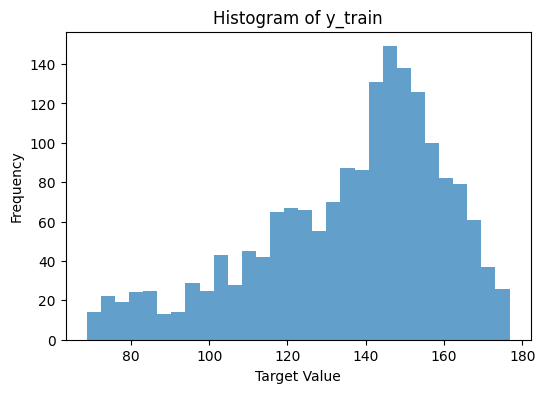

In [6]:
plt.figure(figsize=(6, 4))
plt.hist(y_train_raw, bins=30, alpha=0.7)
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.title("Histogram of y_train")
plt.show()

To feed the data into the CNN, we first need to convert the dataframe into a so-called tensor (in this case a 3D array).

In [7]:
def convert_df_to_tensor(df):
    tensor = np.array([[df.iloc[i, j].values for j in range(df.shape[1])] for i in range(len(df))])
    tensor = np.transpose(tensor, (0, 2, 1))

    for i, j in zip(range(len(df)), range(len(df.columns))):
        assert np.array_equal(df.iloc[i, j].values, tensor[i, :, j])

    return tensor


X_train_tensor = convert_df_to_tensor(X_train_raw)
X_test_tensor = convert_df_to_tensor(X_test_raw)

Let us check the shapes orf the resulting tensors.

In [8]:
print(X_train_tensor.shape)
print(X_test_tensor.shape)

(1768, 1000, 5)
(1328, 1000, 5)


The training data set has 1768 samples, each consisting of 5 channels (PPG and acceleration signals) with a length of 1000 time steps (which are 8 seconds at 125 Hz).

Neural networks are generally trained on normalized data.
We will use a leaky ReLU activation function in our CNN, which works best with input data within a [0, 1] range.

Unfortunately the `TimeSeriesScalerMinMax` from `tslearn` needs the data in the shape (n_samples, n_timestamps, n_channels), while the CNN expects (n_samples, n_channels, n_timestamps), so we need to swap the last two axes again after scaling.

In [9]:
scaler_x = TimeSeriesScalerMinMax()
X_train = scaler_x.fit_transform(X_train_tensor, per_feature=True)
X_test = scaler_x.transform(X_test_tensor, per_feature=True)

scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1))
y_test = scaler_y.transform(y_test_raw.reshape(-1, 1))

X_train = np.transpose(X_train, (0, 2, 1))
X_test = np.transpose(X_test, (0, 2, 1))

In [10]:
print(X_train.shape)
print(X_test.shape)

(1768, 5, 1000)
(1328, 5, 1000)


### Regressor

The `CNNRegressor` from `sktime` can now be used to create and train the convolutional neural network for time series regression.

In [11]:
regressor = CNNRegressor(
    activation="linear",
    activation_hidden="leaky_relu",
    batch_size=64,
    metrics=[],
    n_conv_layers=5,
    n_epochs=80,
    optimizer=Adam(),
    random_state=42,
    verbose=True,
)

regressor.fit(X_train, y_train)

E0000 00:00:1763419291.413804  479034 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763419291.419347  479034 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 5)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 994, 6)         │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 331, 6)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 325, 12)        │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 108, 12)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 102, 12)        │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_2             │ (None, 34, 12)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 28, 12)         │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_3             │ (None, 9, 12)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 3, 12)          │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_4             │ (None, 1, 12)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805 (14.86 KB)

 Trainable params: 3,805 (14.86 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1359
Epoch 2/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0539
Epoch 3/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0490
Epoch 4/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0466
Epoch 5/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0449
Epoch 6/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0428
Epoch 7/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0394
Epoch 8/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0386
Epoch 9/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0377
Epoch 10/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0368
Epoch 11/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0363
Epoch 12/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0357
Epoch 13/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0351
Epoch 14/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0344
Epoch 15/80
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0338
Epoc

CNNRegressor(activation_hidden='leaky_relu', batch_size=64, metrics=[],
             n_conv_layers=5, n_epochs=80,
             optimizer=<keras.src.optimizers.adam.Adam object at 0x7dc04649e270>,
             random_state=42, verbose=True)

To verify the performance of the trained model, we now predict the target values for the test set and compute the _root mean squared error_ (RMSE) between the predicted and true target values.

Keep in mind, that we have to inverse transform the predicted target values back to the original scale before computing the RMSE.

In [12]:
y_pred_scaled = regressor.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

rmse = root_mean_squared_error(y_test_raw, y_pred)
print(f"RMSE: {rmse:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
RMSE: 28.7418


The RMSE indicates that the model is not performing very well on this task.

Let us visualize the residuals (the difference between the true and predicted target values) to get a better understanding of the model's performance.

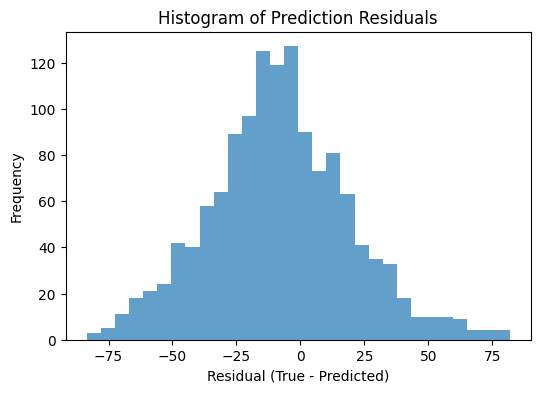

In [13]:
plt.figure(figsize=(6, 4))
plt.hist(y_test_raw - y_pred.flatten(), bins=30, alpha=0.7)
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Residuals")
plt.show()

A scatter plot showing true against predicted values reveals that the model tends to overestimate smaller values and underestimate larger values.

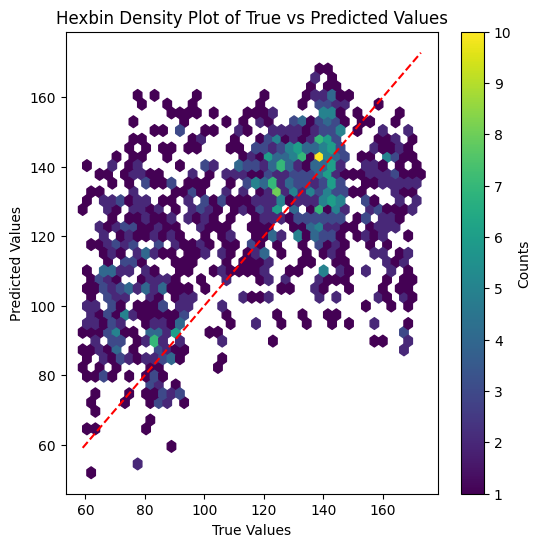

In [14]:
plt.figure(figsize=(6, 6))
plt.hexbin(y_test_raw, y_pred.flatten(), gridsize=40, cmap="viridis", mincnt=1)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Hexbin Density Plot of True vs Predicted Values")
plt.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], "r--")
plt.colorbar(label="Counts")
plt.show()

Especially when encountering a model that performs worse than expected, it is important to analyze potential reasons for this behavior.

Here, we predict the training set using the trained model.
Usually, the training error should be significantly lower than the test error.
If this is not the case, we can suspect issues with the code, model (architecture) or with the data itself.

_Plotting the histogram of residuals on training set_

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


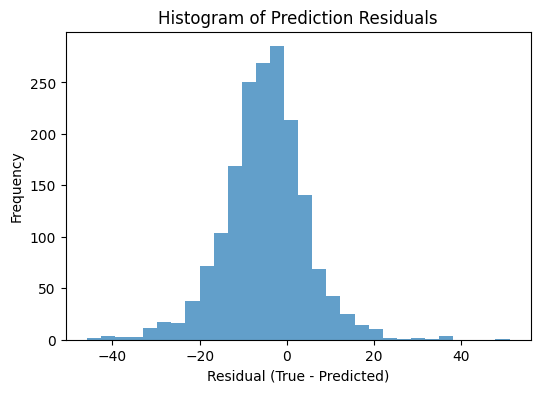

In [15]:
y_pred_train_scaled = regressor.predict(X_train)
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1))

plt.figure(figsize=(6, 4))
plt.hist(y_train_raw - y_pred_train.flatten(), bins=30, alpha=0.7)
plt.xlabel("Residual (True - Predicted)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Residuals")
plt.show()

_Plotting the scatter plot of true vs. predicted values on training set_

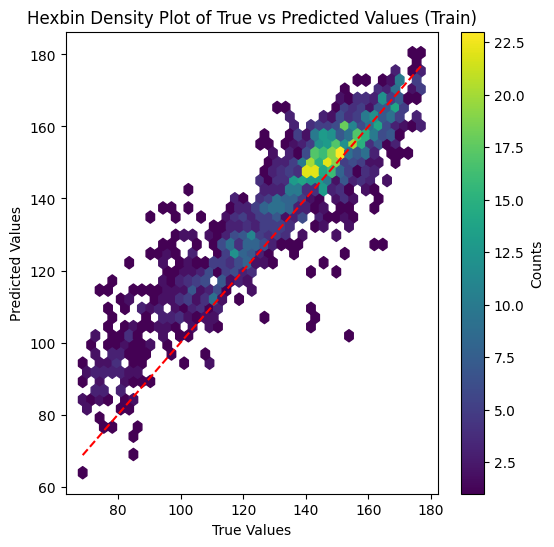

In [16]:
plt.figure(figsize=(6, 6))
plt.hexbin(y_train_raw, y_pred_train.flatten(), gridsize=40, cmap="viridis", mincnt=1)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Hexbin Density Plot of True vs Predicted Values (Train)")
plt.plot([y_train_raw.min(), y_train_raw.max()], [y_train_raw.min(), y_train_raw.max()], "r--")
plt.colorbar(label="Counts")
plt.show()

The model is able to fit the training data quite well, indicating that the code is implemented correctly and the model architecture is complex enough to capture the underlying patterns in the data.
Still, the performance on the test set is significantly worse than on the training set.
This suggests that the model is likely overfitting the data, which could be due to various factors such as e.g. insufficient training data, or lack of regularization or that the test data distribution differs significantly from the training data distribution.

While these results are not fully satisfying, the results align with those reported by @{tan2021} for other simpler neural network architectures on this dataset.